In [ ]:
# شبیه‌سازی Cold Start در سیستم‌های Serverless

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile

# -----------------------------
# 1. تنظیمات اولیه
# -----------------------------

np.random.seed(42)

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

functions = ["login", "search", "payment", "upload", "report"]

# احتمال درخواست برای هر تابع
function_probabilities = {
    "login": 0.25,
    "search": 0.35,
    "payment": 0.15,
    "upload": 0.15,
    "report": 0.10
}

# زمان اجرای عادی هر تابع بر حسب میلی‌ثانیه
warm_latency = {
    "login": 45,
    "search": 70,
    "payment": 100,
    "upload": 120,
    "report": 90
}

# تأخیر اضافی در حالت Cold Start بر حسب میلی‌ثانیه
cold_start_delay = {
    "login": 700,
    "search": 850,
    "payment": 1000,
    "upload": 1200,
    "report": 950
}

NUM_REQUESTS = 1000
IDLE_TIMEOUT = 120  # اگر تابع 120 ثانیه استفاده نشود، خاموش فرض می‌شود

# -----------------------------
# 2. تولید درخواست‌های تصادفی
# -----------------------------

arrival_times = np.cumsum(np.random.exponential(scale=8, size=NUM_REQUESTS))

requested_functions = np.random.choice(
    functions,
    size=NUM_REQUESTS,
    p=[function_probabilities[f] for f in functions]
)

requests = pd.DataFrame({
    "time": arrival_times,
    "function": requested_functions
})

# -----------------------------
# 3. تابع شبیه‌سازی برای هر سیاست
# -----------------------------

def simulate_policy(policy_name):
    warm_functions = {}
    response_times = []
    cold_starts = []
    resource_usage = []

    # در روش همیشه آماده، همه تابع‌ها از ابتدا آماده‌اند
    if policy_name == "always_warm":
        for f in functions:
            warm_functions[f] = 0

    # در روش هوشمند، دو تابع پرتکرار همیشه آماده نگه داشته می‌شوند
    smart_warm_functions = ["search", "login"]

    if policy_name == "smart_warm":
        for f in smart_warm_functions:
            warm_functions[f] = 0

    for _, row in requests.iterrows():
        current_time = row["time"]
        func = row["function"]

        # حذف تابع‌هایی که مدت زیادی استفاده نشده‌اند
        if policy_name in ["on_demand", "smart_warm"]:
            to_remove = []
            for f, last_used in warm_functions.items():
                if policy_name == "smart_warm" and f in smart_warm_functions:
                    continue
                if current_time - last_used > IDLE_TIMEOUT:
                    to_remove.append(f)

            for f in to_remove:
                del warm_functions[f]

        # بررسی Cold Start
        if policy_name == "always_warm":
            is_cold = False

        elif policy_name == "smart_warm" and func in smart_warm_functions:
            is_cold = False

        else:
            is_cold = func not in warm_functions

        # محاسبه زمان پاسخ
        jitter = np.random.normal(loc=0, scale=5)
        latency = warm_latency[func] + max(jitter, 0)

        if is_cold:
            latency += cold_start_delay[func]

        response_times.append(latency)
        cold_starts.append(1 if is_cold else 0)

        # بعد از اجرا، تابع آماده فرض می‌شود
        warm_functions[func] = current_time

        # در روش هوشمند، تابع‌های پرتکرار همیشه آماده می‌مانند
        if policy_name == "smart_warm":
            for f in smart_warm_functions:
                warm_functions[f] = current_time

        resource_usage.append(len(warm_functions))

    result = {
        "policy": policy_name,
        "average_response_time": np.mean(response_times),
        "max_response_time": np.max(response_times),
        "cold_start_count": np.sum(cold_starts),
        "average_resource_usage": np.mean(resource_usage)
    }

    detailed = pd.DataFrame({
        "time": requests["time"],
        "function": requests["function"],
        "response_time": response_times,
        "cold_start": cold_starts,
        "resource_usage": resource_usage
    })

    return result, detailed

# -----------------------------
# 4. اجرای سه روش
# -----------------------------

policies = {
    "on_demand": "بدون آماده‌سازی اولیه",
    "always_warm": "همیشه آماده نگه داشتن همه تابع‌ها",
    "smart_warm": "آماده‌سازی هوشمند تابع‌های پرتکرار"
}

summary_results = []
details = {}

for policy in policies.keys():
    result, detailed = simulate_policy(policy)
    summary_results.append(result)
    details[policy] = detailed

summary_df = pd.DataFrame(summary_results)

summary_df["policy_fa"] = summary_df["policy"].map(policies)

# ذخیره جدول نتایج
summary_df.to_csv(f"{RESULTS_DIR}/results_table.csv", index=False)

summary_df

,policy,average_response_time,max_response_time,cold_start_count,average_resource_usage,policy_fa
0,on_demand,141.775473,1330.370413,62,4.624,بدون آماده‌سازی اولیه
1,always_warm,80.761714,134.342015,0,5.000,همیشه آماده نگه داشتن همه تابع‌ها
2,smart_warm,133.336863,1330.465990,51,4.656,آماده‌سازی هوشمند تابع‌های پرتکرار


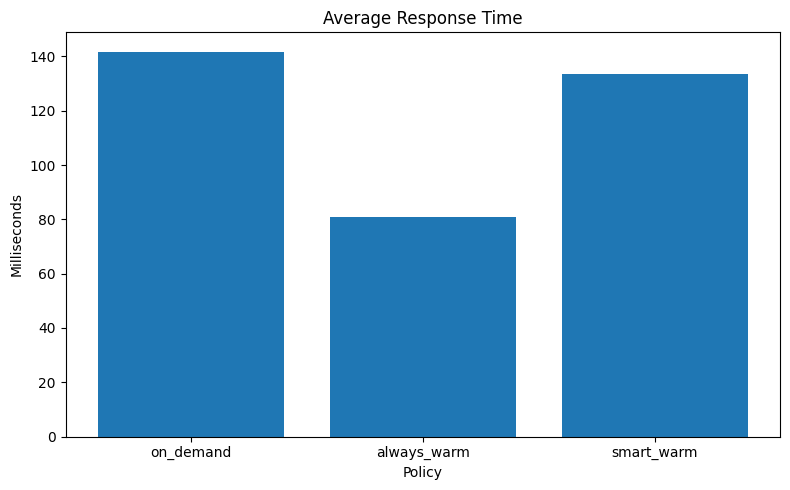

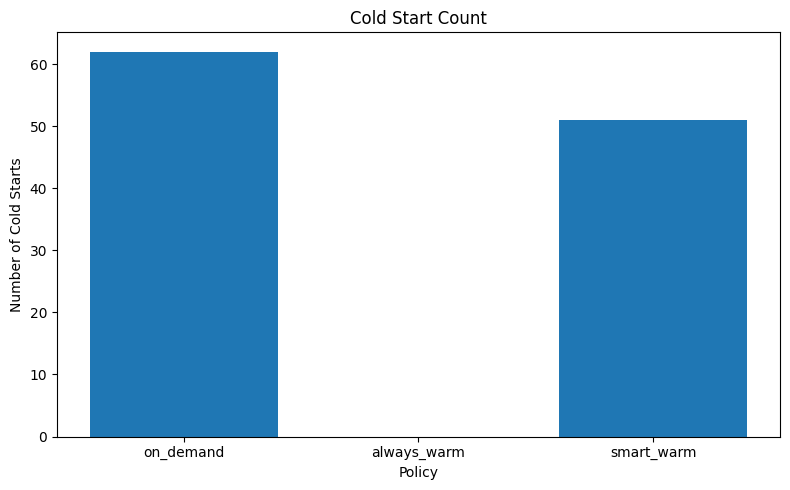

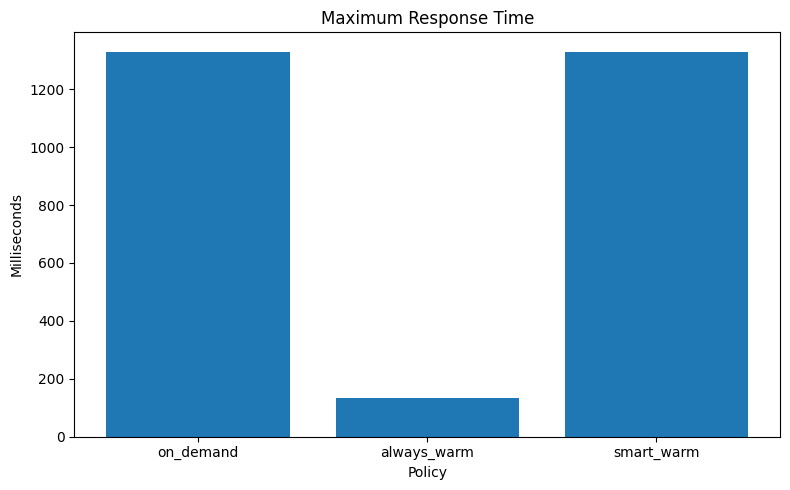

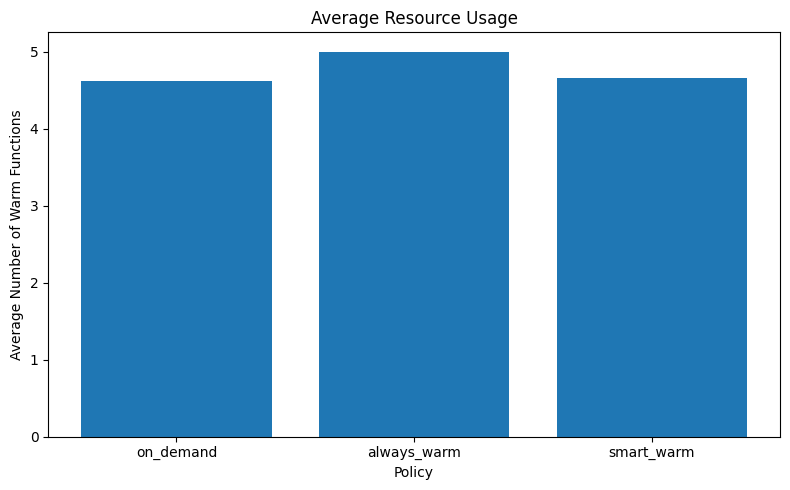

In [ ]:
# -----------------------------
# 5. رسم نمودارها
# -----------------------------

plt.figure(figsize=(8, 5))
plt.bar(summary_df["policy"], summary_df["average_response_time"])
plt.title("Average Response Time")
plt.xlabel("Policy")
plt.ylabel("Milliseconds")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/average_response_time.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["policy"], summary_df["cold_start_count"])
plt.title("Cold Start Count")
plt.xlabel("Policy")
plt.ylabel("Number of Cold Starts")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/cold_start_count.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["policy"], summary_df["max_response_time"])
plt.title("Maximum Response Time")
plt.xlabel("Policy")
plt.ylabel("Milliseconds")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/max_response_time.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["policy"], summary_df["average_resource_usage"])
plt.title("Average Resource Usage")
plt.xlabel("Policy")
plt.ylabel("Average Number of Warm Functions")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/resource_usage.png", dpi=300)
plt.show()

In [ ]:
# -----------------------------
# 6. ساخت فایل ZIP از نتایج
# -----------------------------

zip_filename = "serverless_cold_start_results.zip"

with zipfile.ZipFile(zip_filename, "w") as zipf:
    for filename in os.listdir(RESULTS_DIR):
        zipf.write(os.path.join(RESULTS_DIR, filename), filename)

print("فایل نتایج ساخته شد:", zip_filename)

فایل نتایج ساخته شد: serverless_cold_start_results.zip
